# Chapter 8: Vector Fields

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `174-204`, inspected through the course `source_map.json` and a local PDF text extraction of the Chapter 8 page span.

**Chapter Goal.** Treat a vector field as a smooth section of the tangent bundle, then follow the same object through four increasingly structural viewpoints: a coordinate expression, a derivation of smooth functions, a field related to another field by a smooth map, and finally an element of the Lie algebra of a Lie group.

**Source Landmarks Used.** The source span is organized around vector fields on manifolds; vector fields as derivations of `C^\infty(M)`; vector fields and smooth maps, including related fields, pushforwards by diffeomorphisms, and submanifold restrictions; Lie brackets and their coordinate formula, identities, and naturality; the Lie algebra of a Lie group; left-invariant fields; induced Lie algebra homomorphisms; Lie subgroups; and a problem set emphasizing frames, pushforward failure modes, products, lifts, derivations, matrix groups, and ideals.

The prose, examples, diagrams, code, and checks below are original teaching material. They use the source only for orientation, terminology, and coverage; there are no copied passages, source page crops, or textbook figures.


## Visual Storyboard

| Step | Source concept | Representation | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| 1 | Vector fields as smooth sections | Circle field plus unrolled tangent-bundle coordinates | The projection of each selected tangent vector returns the base point | `radial_dot = 0`, unit tangent norm |
| 2 | Coordinate expressions and smoothness | Rotation field in Cartesian and polar components | The same geometric field has different coordinate coefficients | `X(r)=0`, `X(theta)=1` on the punctured plane |
| 3 | Vector fields acting on functions | Contours of `f` with `Xf` as the directional derivative readout | Arrows point across level curves exactly where `Xf` is nonzero | Derivation product rule residual is zero |
| 4 | Smooth maps and related fields | Circle immersion plus fold-map failure panel and HTML artifact | A related field is single-valued on the target; a bad pushforward is not | `dF(X)=Y\circ F`; fold preimages disagree |
| 5 | Lie brackets | Three quiver panels for `X`, `Y`, and `[X,Y]` | The commutator is what remains after second-order cancellation | coordinate brackets, Jacobi, and product-rule checks |
| 6 | Lie algebra of a Lie group | Left-invariant fields on the affine group half-plane | Values at the identity propagate by left translation | `[E_1,E_2]=E_2` and matrix commutator agreement |
| 7 | Applied lab | Parameterized bracket family | Commuting fields are a special parameter value, not the generic case | symbolic and sampled bracket summary |


## Library Routing

| Library | Chapter role | Why it fits | Artifact/check target |
| --- | --- | --- | --- |
| Matplotlib | Durable 2D diagrams and vector-field plots | Chapter 8 is mostly local and first-order, so labeled static vector fields are the clearest inspection surface | PNG figures under `artifacts/chapter-08-vector-fields/figures/` |
| SymPy | Coordinate and bracket identities | Lie brackets, derivations, and induced homomorphism checks are exact symbolic identities in small coordinate models | JSON checks under `artifacts/chapter-08-vector-fields/checks/` |
| NetworkX | Proof/concept dependency graph | Naturality and induced homomorphisms are dependency chains; a directed graph exposes which result feeds which | `vector-fields-concept-dependency.png` |
| Plotly | One focused interactive artifact | The fold-map failure is best inspected by toggling source and target data in one self-contained HTML view | `pushforward-fold-failure.html` |
| NumPy | Sampling smooth fields on grids | Visual artifacts need reproducible finite samples of the smooth models | grid statistics in JSON sanity checks |


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-08-vector-fields"
UNIT_TITLE = "Vector Fields"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
})

source_span = {
    "unit": UNIT_TITLE,
    "printed_pages": "174-204",
    "pdf": "Introduction to Smooth Manifolds.pdf",
    "source_map_focus": "Vector fields, smooth maps, Lie brackets, and Lie algebra of a Lie group.",
    "sections_inspected": [
        "Vector Fields on Manifolds",
        "Vector Fields as Derivations of C^infinity(M)",
        "Vector Fields and Smooth Maps",
        "Lie Brackets",
        "The Lie Algebra of a Lie Group",
        "Problems",
    ],
    "copyright_note": "Source used for structure, terminology, theorem orientation, and coverage only.",
}
source_span_path = save_json(source_span, CHECKS / "source-span-vector-fields.json")

routing_rows = [
    {
        "concept": "smooth section X: M -> TM",
        "representation": "circle field and tangent-bundle graph",
        "library": "Matplotlib, NumPy",
        "why": "the section condition is visible as base point plus tangent arrow",
        "artifact": "figures/vector-fields-section-as-graph.png",
        "check": "checks/vector-fields-section-as-graph.json",
    },
    {
        "concept": "coordinate expression",
        "representation": "rotation field in Cartesian and polar components",
        "library": "Matplotlib, SymPy",
        "why": "the same field can be checked exactly in two coordinate languages",
        "artifact": "figures/coordinate-expression-rotation-field.png",
        "check": "checks/coordinate-expression-rotation-field.json",
    },
    {
        "concept": "vector field as derivation",
        "representation": "contours of f and signed Xf background",
        "library": "Matplotlib, SymPy",
        "why": "directional differentiation is directly readable from level curves",
        "artifact": "figures/vector-field-acts-on-function.png",
        "check": "checks/vector-field-acts-on-function.json",
    },
    {
        "concept": "related fields and pushforwards",
        "representation": "circle related field and fold-map failure",
        "library": "Matplotlib, Plotly, SymPy",
        "why": "the target field must be single-valued over fibers",
        "artifact": "figures/pushforward-related-and-failure.png; html/pushforward-fold-failure.html",
        "check": "checks/pushforward-related-and-failure.json",
    },
    {
        "concept": "Lie bracket",
        "representation": "quiver comparison of X, Y, and [X,Y]",
        "library": "Matplotlib, SymPy",
        "why": "the commutator is a new first-order field with exact coordinate checks",
        "artifact": "figures/lie-bracket-coordinate-check.png",
        "check": "checks/lie-bracket-coordinate-checks.json",
    },
    {
        "concept": "Lie algebra of a Lie group",
        "representation": "left-invariant fields on the affine group",
        "library": "Matplotlib, SymPy",
        "why": "a two-dimensional nonabelian Lie group is visible as a half-plane",
        "artifact": "figures/affine-group-left-invariant-fields.png",
        "check": "checks/affine-group-left-invariant-fields.json",
    },
]
routing_path = save_csv(routing_rows, TABLES / "vector-fields-library-routing.csv")

storyboard_rows = [
    {
        "order": idx + 1,
        "visual": row["artifact"],
        "concept": row["concept"],
        "inspection_target": row["why"],
        "validation": row["check"],
    }
    for idx, row in enumerate(routing_rows)
]
storyboard_path = save_csv(storyboard_rows, TABLES / "vector-fields-visual-storyboard.csv")

display(Markdown(f"Artifacts root: `{ARTIFACT_ROOT.relative_to(BOOK_ROOT)}`"))
display_artifact(routing_path, width=760)
display_artifact(storyboard_path, width=760)


Artifacts root: `artifacts\chapter-08-vector-fields`

[vector-fields-library-routing.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-08-vector-fields/tables/vector-fields-library-routing.csv)

[vector-fields-visual-storyboard.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-08-vector-fields/tables/vector-fields-visual-storyboard.csv)

## Translation Guide

Chapter 8 can be read as a sequence of translations.

| Book-side language | Computational language in this notebook |
| --- | --- |
| A rough field assigns `X_p in T_pM` | a sampled rule that attaches one tangent vector to each base point |
| Smoothness of `X` | smooth component functions in any smooth chart, checked through symbolic coefficients or stable samples |
| `X` acts on `f` | the first-order operator `Xf = sum_i X^i partial_i f` |
| `X` and `Y` are `F`-related | the identity `dF_p(X_p)=Y_{F(p)}` plus single-valuedness over fibers |
| Pushforward by a diffeomorphism | a target field computed by transporting from the unique preimage |
| Lie bracket | the commutator `XY-YX`, which is first-order even though `XY` and `YX` separately are second-order |
| Lie algebra of `G` | the left-invariant fields, equivalently the tangent space at the identity with a transported bracket |

A recurring failure mode is useful: many formulas that look pointwise correct fail when a map has multiple preimages or when a field is not tangent to a submanifold. The notebook keeps those failures visible instead of hiding them behind notation.


## Concept Dependency Graph

The chapter's proof logic is not linear. The directed graph below records one useful reading route: sections give local coefficients; local coefficients let vector fields act on functions; derivations make the Lie bracket coordinate-free; related fields make brackets natural; left-invariant fields turn that bracket into a finite-dimensional Lie algebra.


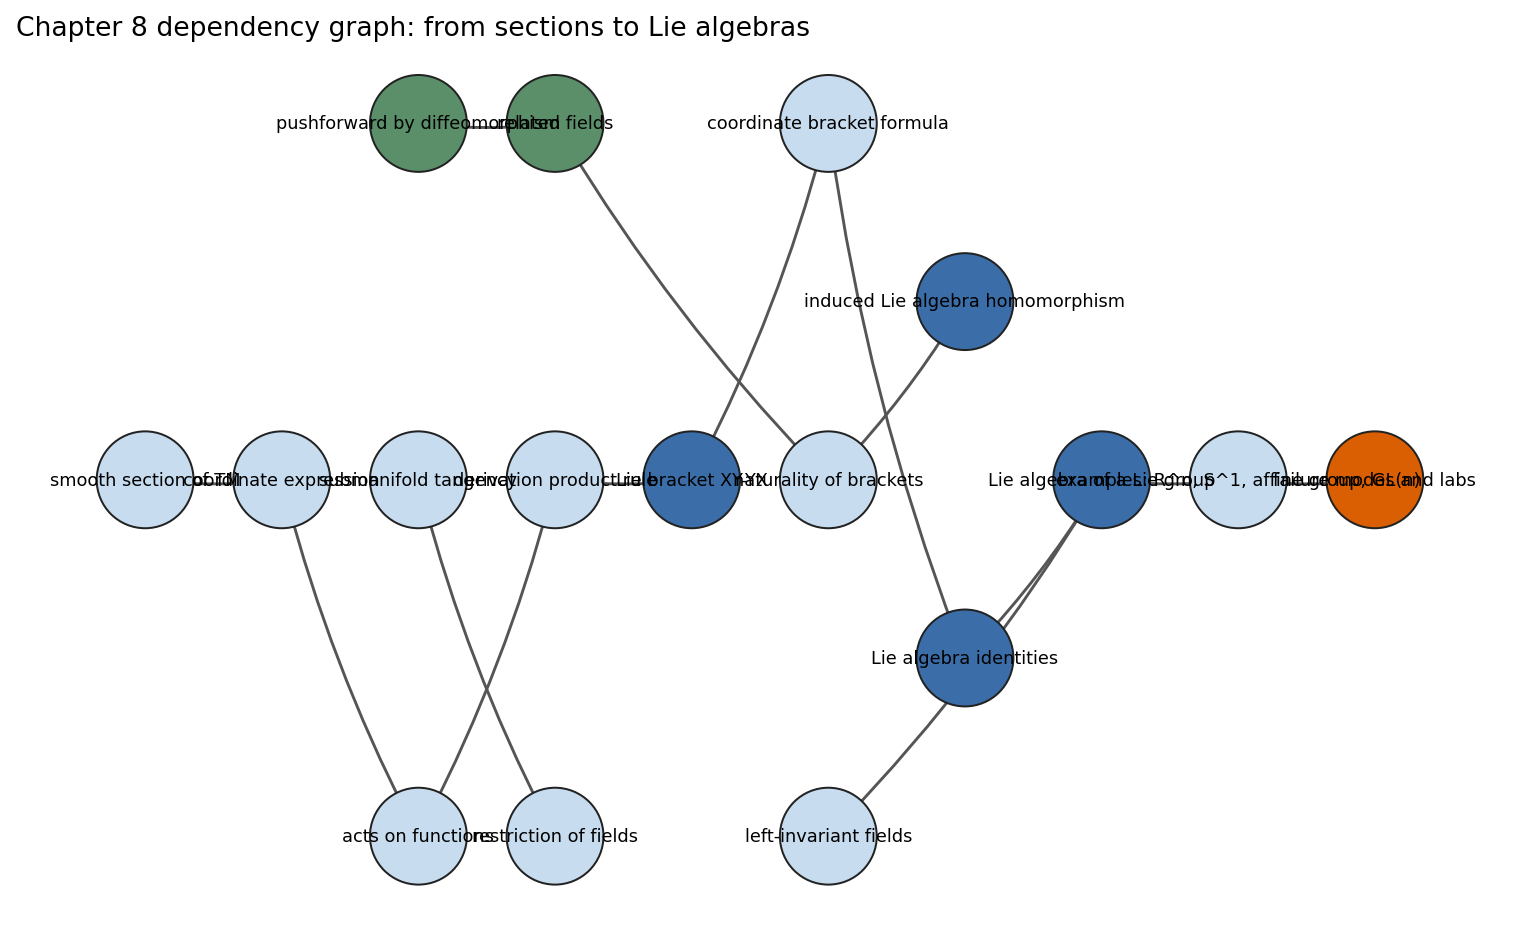

In [2]:
dependency_edges = [
    ("smooth section of TM", "coordinate expression"),
    ("coordinate expression", "acts on functions"),
    ("acts on functions", "derivation product rule"),
    ("derivation product rule", "Lie bracket XY-YX"),
    ("Lie bracket XY-YX", "coordinate bracket formula"),
    ("related fields", "naturality of brackets"),
    ("pushforward by diffeomorphism", "related fields"),
    ("submanifold tangency", "restriction of fields"),
    ("coordinate bracket formula", "Lie algebra identities"),
    ("naturality of brackets", "induced Lie algebra homomorphism"),
    ("left-invariant fields", "Lie algebra of a Lie group"),
    ("Lie algebra identities", "Lie algebra of a Lie group"),
    ("Lie algebra of a Lie group", "examples: R^n, S^1, affine group, GL(n)"),
    ("examples: R^n, S^1, affine group, GL(n)", "failure modes and labs"),
]
G = nx.DiGraph()
G.add_edges_from(dependency_edges)
layers = {
    "smooth section of TM": 0,
    "coordinate expression": 1,
    "acts on functions": 2,
    "derivation product rule": 3,
    "Lie bracket XY-YX": 4,
    "coordinate bracket formula": 5,
    "Lie algebra identities": 6,
    "related fields": 3,
    "pushforward by diffeomorphism": 2,
    "submanifold tangency": 2,
    "restriction of fields": 3,
    "naturality of brackets": 5,
    "induced Lie algebra homomorphism": 6,
    "left-invariant fields": 5,
    "Lie algebra of a Lie group": 7,
    "examples: R^n, S^1, affine group, GL(n)": 8,
    "failure modes and labs": 9,
}
for node, layer in layers.items():
    G.nodes[node]["layer"] = layer
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.8)
fig, ax = plt.subplots(figsize=(12, 7))
node_colors = []
for node in G.nodes:
    if "failure" in node:
        node_colors.append("#d95f02")
    elif "Lie algebra" in node or "Lie bracket" in node:
        node_colors.append("#3b6ea8")
    elif "related" in node or "pushforward" in node:
        node_colors.append("#5b8f6a")
    else:
        node_colors.append("#c7dcef")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.3, edge_color="#555555", connectionstyle="arc3,rad=0.06")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1900, node_color=node_colors, edgecolors="#222222", linewidths=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Chapter 8 dependency graph: from sections to Lie algebras")
ax.axis("off")
concept_graph_path = save_matplotlib(fig, FIGURES / "vector-fields-concept-dependency.png")
plt.close(fig)
concept_graph_check_path = save_json(
    {
        "node_count": G.number_of_nodes(),
        "edge_count": G.number_of_edges(),
        "has_path_section_to_lie_algebra": nx.has_path(G, "smooth section of TM", "Lie algebra of a Lie group"),
        "has_path_related_to_induced": nx.has_path(G, "related fields", "induced Lie algebra homomorphism"),
    },
    CHECKS / "vector-fields-concept-dependency.json",
)
display_artifact(concept_graph_path, width=880)


## Vector Fields as Smooth Sections

A vector field is not just a bag of arrows. It is a section of the tangent bundle: it selects one tangent vector over each base point, and the bundle projection sends that selected vector back to the point where it lives. The first figure uses the unit circle because tangency is visible: every arrow is perpendicular to the radius. The right panel unwraps the tangent bundle of the circle into coordinates `(theta, v)` and shows the chosen section as the graph `v=1`.


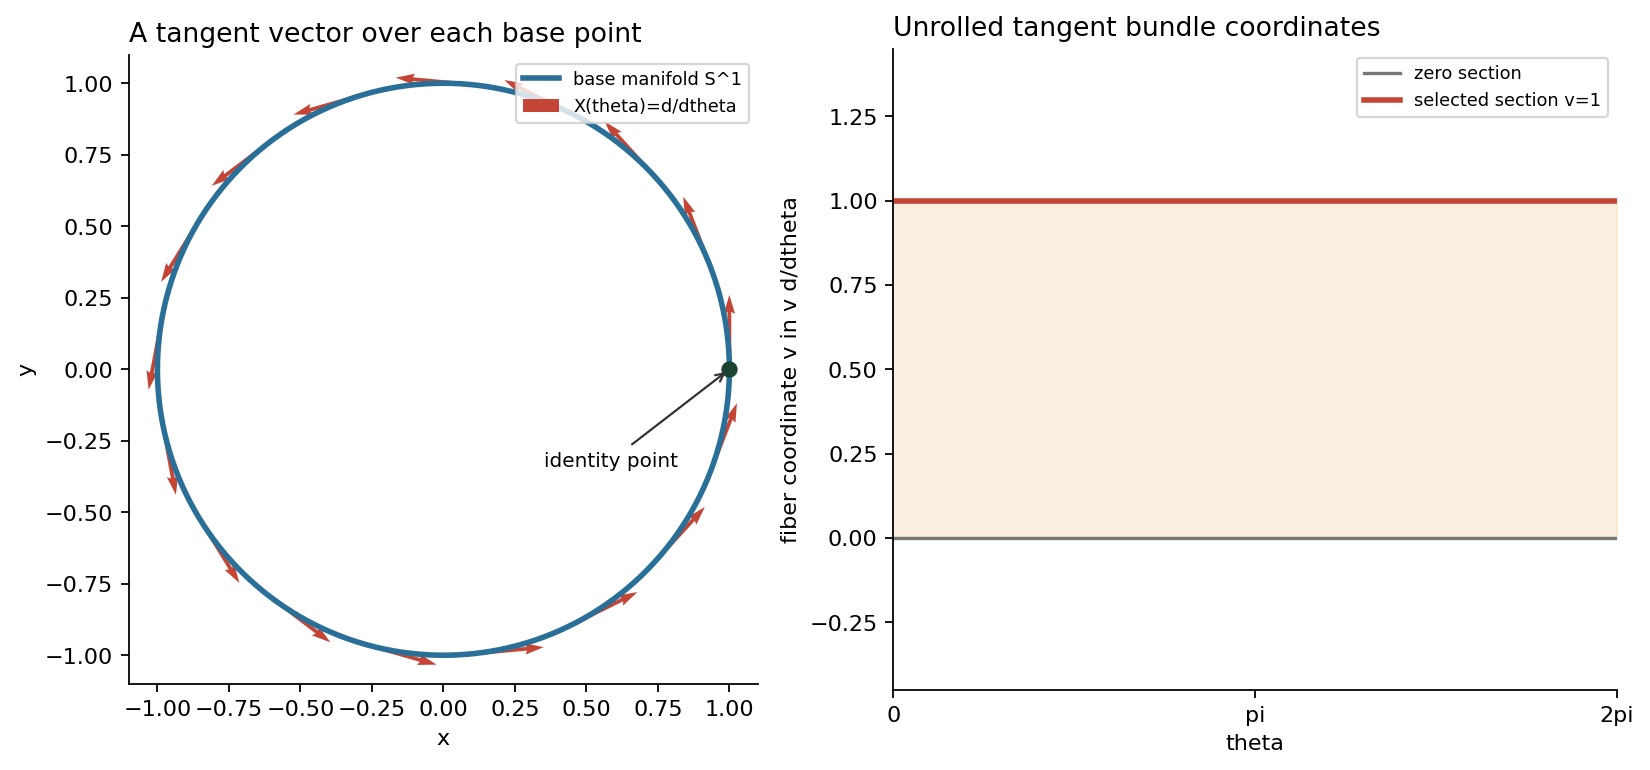

In [3]:
theta = np.linspace(0, 2 * np.pi, 400)
pts = np.column_stack([np.cos(theta), np.sin(theta)])
tangent = np.column_stack([-np.sin(theta), np.cos(theta)])
sample_theta = np.linspace(0, 2 * np.pi, 17, endpoint=False)
sample_pts = np.column_stack([np.cos(sample_theta), np.sin(sample_theta)])
sample_tangent = np.column_stack([-np.sin(sample_theta), np.cos(sample_theta)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
ax.plot(pts[:, 0], pts[:, 1], color="#2a6f97", lw=2.5, label="base manifold S^1")
ax.quiver(
    sample_pts[:, 0],
    sample_pts[:, 1],
    0.26 * sample_tangent[:, 0],
    0.26 * sample_tangent[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#c44536",
    width=0.006,
    label="X(theta)=d/dtheta",
)
ax.scatter([1], [0], s=40, color="#1b4332", zorder=3)
ax.annotate("identity point", (1, 0), xytext=(0.35, -0.34), arrowprops={"arrowstyle": "->", "color": "#333333"}, fontsize=9)
ax.set_aspect("equal")
ax.set_title("A tangent vector over each base point")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.plot(theta, np.zeros_like(theta), color="#777777", lw=1.5, label="zero section")
ax.plot(theta, np.ones_like(theta), color="#c44536", lw=2.5, label="selected section v=1")
ax.fill_between(theta, 0, 1, color="#f2cc8f", alpha=0.28)
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-0.45, 1.45)
ax.set_xlabel("theta")
ax.set_ylabel("fiber coordinate v in v d/dtheta")
ax.set_title("Unrolled tangent bundle coordinates")
ax.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
ax.legend(loc="upper right", fontsize=8)

section_path = save_matplotlib(fig, FIGURES / "vector-fields-section-as-graph.png")
plt.close(fig)

radial_dot = np.sum(sample_pts * sample_tangent, axis=1)
norm_error = np.linalg.norm(sample_tangent, axis=1) - 1.0
section_check = {
    "model": "unit circle with section X=d/dtheta",
    "max_abs_radial_dot": float(np.max(np.abs(radial_dot))),
    "max_abs_norm_error": float(np.max(np.abs(norm_error))),
    "projection_returns_base_parameter": True,
    "smooth_section_interpretation": "theta -> (theta, 1) in the trivialized tangent bundle of S^1",
}
section_check_path = save_json(section_check, CHECKS / "vector-fields-section-as-graph.json")
display_artifact(section_path, width=840)


## Coordinate Expressions: One Field, Two Languages

In a chart, a field becomes `X = X^i partial_i`. A change of coordinates changes the component functions, not the underlying geometric assignment. On the punctured plane, the rotation field

`X = -y partial_x + x partial_y`

is exactly `partial_theta` in polar coordinates: it changes angle but not radius. This is also the first place to notice a domain warning: the polar expression is not a single chart at the origin.


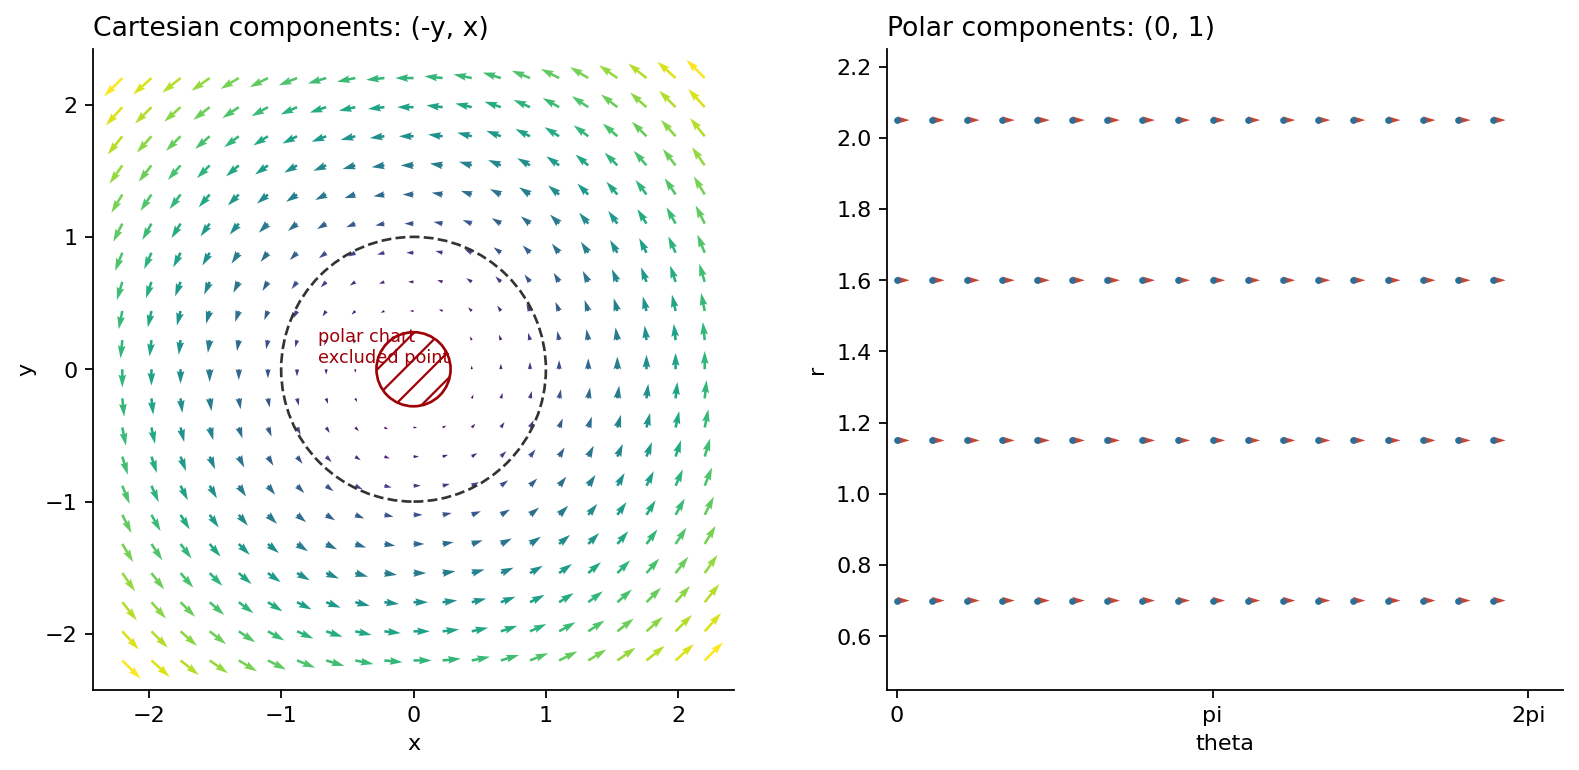

In [4]:
x, y = sp.symbols("x y", real=True)
r2 = x**2 + y**2
X_cart = sp.Matrix([-y, x])
grad_r = sp.Matrix([x / sp.sqrt(r2), y / sp.sqrt(r2)])
grad_theta = sp.Matrix([-y / r2, x / r2])
X_r = sp.simplify((X_cart.dot(grad_r)))
X_theta = sp.simplify((X_cart.dot(grad_theta)))

grid = np.linspace(-2.2, 2.2, 21)
Xg, Yg = np.meshgrid(grid, grid)
R = np.sqrt(Xg**2 + Yg**2)
mask = R > 0.38
U = np.where(mask, -Yg, np.nan)
V = np.where(mask, Xg, np.nan)
speed = np.sqrt(U**2 + V**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
ax.quiver(Xg, Yg, U, V, speed, cmap="viridis", angles="xy", scale_units="xy", scale=16, width=0.004)
circle = plt.Circle((0, 0), 1.0, fill=False, color="#333333", lw=1.2, ls="--")
ax.add_patch(circle)
ax.add_patch(plt.Circle((0, 0), 0.28, color="#ffffff", ec="#9d0208", lw=1.2, hatch="//"))
ax.text(-0.72, 0.05, "polar chart\nexcluded point", fontsize=8, color="#9d0208")
ax.set_aspect("equal")
ax.set_title("Cartesian components: (-y, x)")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax = axes[1]
theta_grid = np.linspace(0, 2 * np.pi, 18, endpoint=False)
radii = np.array([0.7, 1.15, 1.6, 2.05])
for rr in radii:
    ax.plot(theta_grid, np.full_like(theta_grid, rr), ".", color="#2a6f97", ms=4)
    ax.quiver(
        theta_grid,
        np.full_like(theta_grid, rr),
        np.ones_like(theta_grid),
        np.zeros_like(theta_grid),
        angles="xy",
        scale_units="xy",
        scale=8,
        width=0.004,
        color="#c44536",
    )
ax.set_xlim(-0.1, 2 * np.pi + 0.35)
ax.set_ylim(0.45, 2.25)
ax.set_xticks([0, np.pi, 2 * np.pi], ["0", "pi", "2pi"])
ax.set_xlabel("theta")
ax.set_ylabel("r")
ax.set_title("Polar components: (0, 1)")
coordinate_path = save_matplotlib(fig, FIGURES / "coordinate-expression-rotation-field.png")
plt.close(fig)

coordinate_check = {
    "cartesian_field": "X=-y*d/dx + x*d/dy",
    "polar_result": {"X_r": str(X_r), "X_theta": str(X_theta)},
    "punctured_plane_required": True,
    "checks": {
        "radius_constant": X_r == 0,
        "angle_speed_one": sp.simplify(X_theta - 1) == 0,
    },
}
coordinate_check_path = save_json(coordinate_check, CHECKS / "coordinate-expression-rotation-field.json")
display_artifact(coordinate_path, width=840)


## Vector Fields Acting on Functions

Once `X` is smooth, it acts on smooth real-valued functions by directional differentiation. This operator is linear over `R`, not over `C^\infty(M)`, and it satisfies the product rule. The next figure puts that operator into the same picture as level curves: where arrows skim a level curve, `Xf` is near zero; where arrows cut across the contours, `Xf` is large in magnitude.


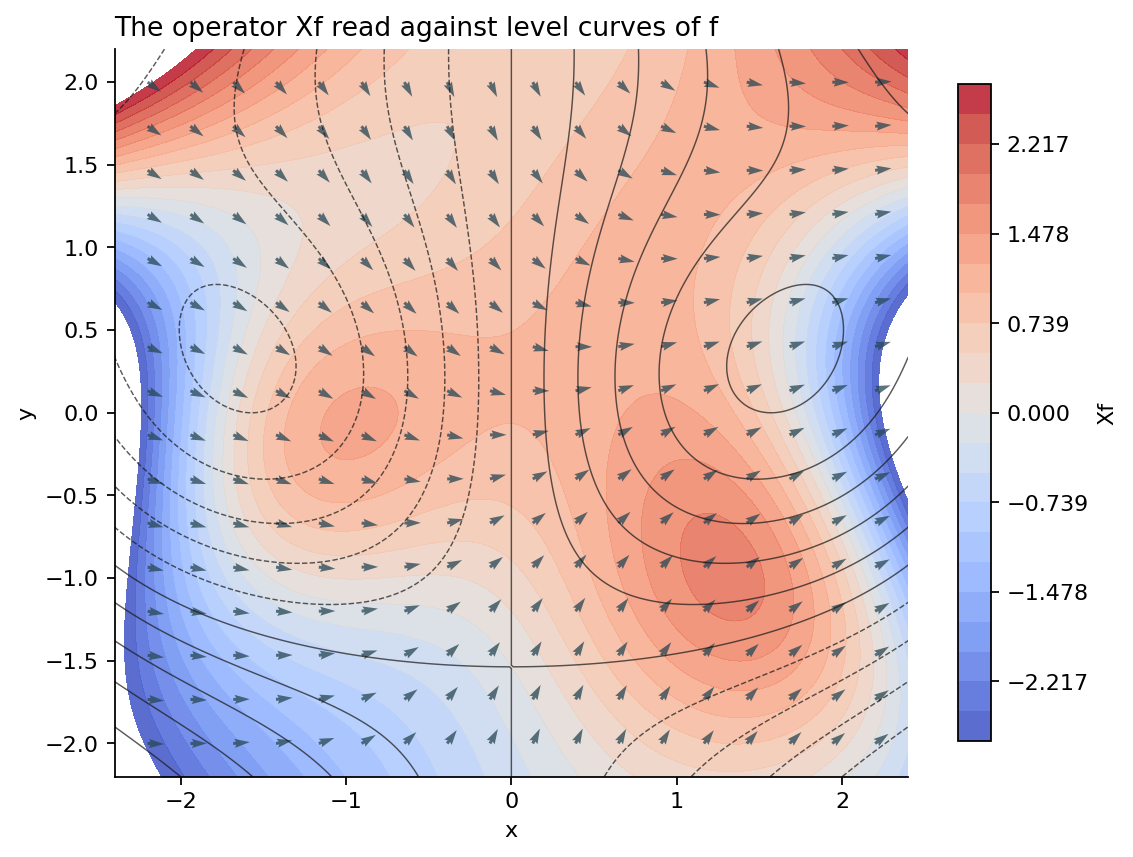

In [5]:
P = 1 + x**2
Q = x - y
f_expr = sp.sin(x) * sp.exp(-y**2 / 2) + sp.Rational(1, 5) * x * y
g_expr = x**2 + y + 2

def X_apply(expr):
    return sp.simplify(P * sp.diff(expr, x) + Q * sp.diff(expr, y))

Xf_expr = sp.simplify(X_apply(f_expr))
product_rule_residual = sp.simplify(X_apply(f_expr * g_expr) - f_expr * X_apply(g_expr) - g_expr * Xf_expr)

xs = np.linspace(-2.4, 2.4, 220)
ys = np.linspace(-2.2, 2.2, 210)
XX, YY = np.meshgrid(xs, ys)
f_num = sp.lambdify((x, y), f_expr, "numpy")
Xf_num = sp.lambdify((x, y), Xf_expr, "numpy")
FF = f_num(XX, YY)
XF = Xf_num(XX, YY)
qx = np.linspace(-2.2, 2.2, 18)
qy = np.linspace(-2.0, 2.0, 16)
QX, QY = np.meshgrid(qx, qy)
QU = 1 + QX**2
QV = QX - QY
qnorm = np.maximum(np.sqrt(QU**2 + QV**2), 1e-9)

fig, ax = plt.subplots(figsize=(8, 6.5))
vmax = float(np.percentile(np.abs(XF), 97))
im = ax.contourf(XX, YY, XF, levels=np.linspace(-vmax, vmax, 23), cmap="coolwarm", alpha=0.86)
ax.contour(XX, YY, FF, levels=11, colors="#1b1b1b", linewidths=0.65, alpha=0.72)
ax.quiver(QX, QY, QU / qnorm, QV / qnorm, color="#264653", alpha=0.75, angles="xy", scale_units="xy", scale=10, width=0.0038)
ax.set_aspect("equal")
ax.set_title("The operator Xf read against level curves of f")
ax.set_xlabel("x")
ax.set_ylabel("y")
cb = fig.colorbar(im, ax=ax, shrink=0.82)
cb.set_label("Xf")
acts_path = save_matplotlib(fig, FIGURES / "vector-field-acts-on-function.png")
plt.close(fig)

acts_check = {
    "field": "X=(1+x^2)*d/dx + (x-y)*d/dy",
    "function": "sin(x)*exp(-y^2/2) + x*y/5",
    "Xf": str(Xf_expr),
    "product_rule_residual": str(product_rule_residual),
    "sample_Xf_range": [float(np.nanmin(XF)), float(np.nanmax(XF))],
    "checks": {"product_rule_exact": product_rule_residual == 0},
}
acts_check_path = save_json(acts_check, CHECKS / "vector-field-acts-on-function.json")
display_artifact(acts_path, width=760)


## Smooth Maps, Related Fields, and Pushforward Failure

If `F:M -> N` is smooth and `X` is a field on `M`, the pointwise vectors `dF_p(X_p)` live over `F(p)`. They form a genuine vector field on `N` only when they are single-valued over the fibers of `F`. A diffeomorphism always has a unique preimage, so its pushforward is well defined. A general smooth map may fail.

The left panel shows a successful related-field identity for the circle parametrization. The right panel shows the fold `F(t)=t^2`: the two preimages of `u=1` push the same source field to opposite target vectors, so no target vector field can represent the pushforward there.


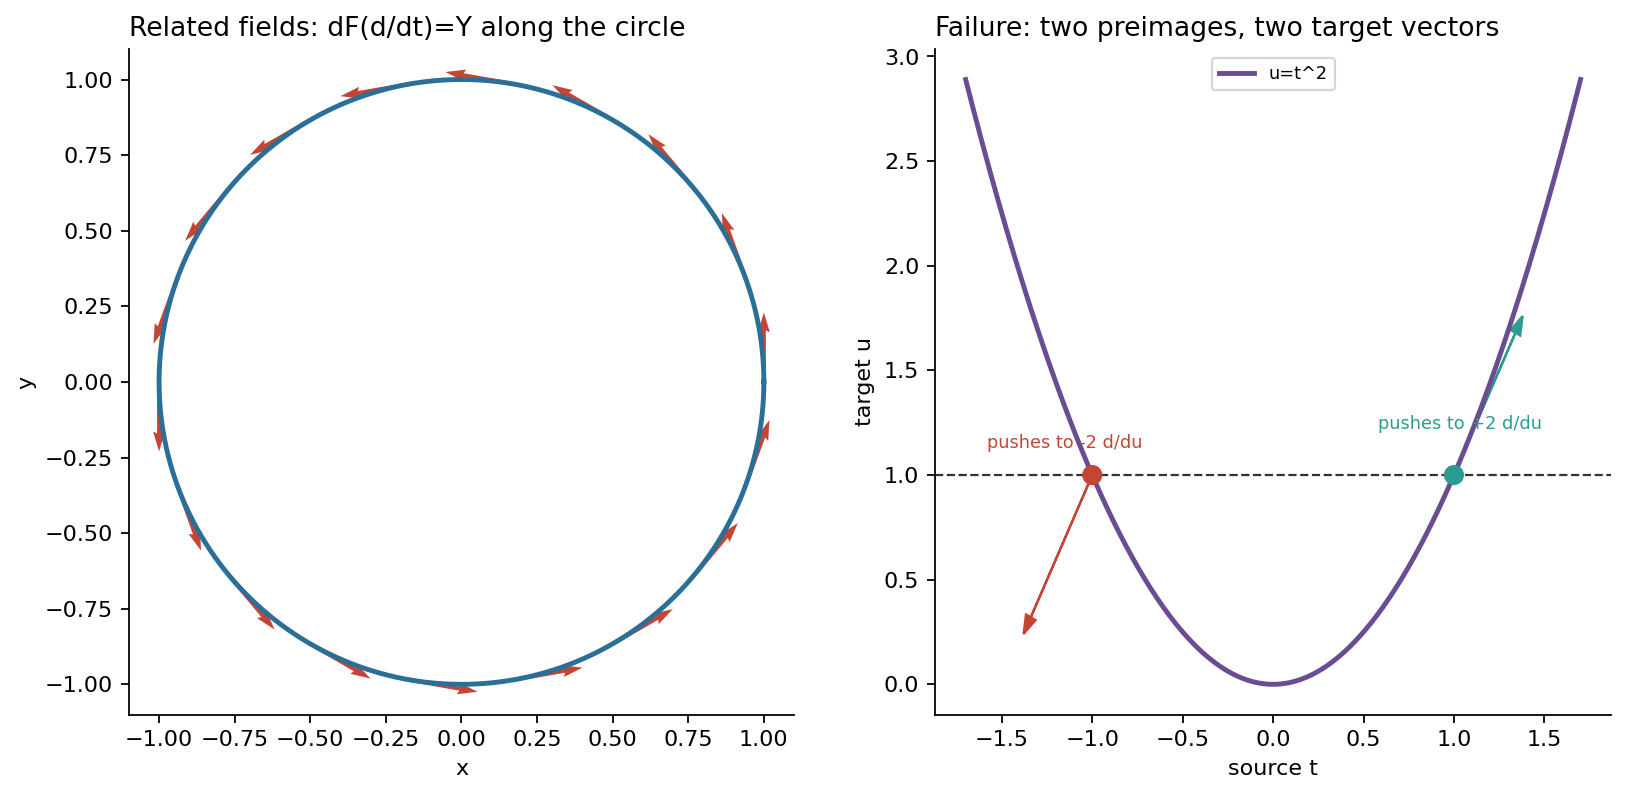

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [6]:
t, u = sp.symbols("t u", real=True)
F_circle = sp.Matrix([sp.cos(t), sp.sin(t)])
dF_dt = sp.diff(F_circle, t)
Y_circle = sp.Matrix([-sp.symbols("yy"), sp.symbols("xx")])
xx, yy = sp.symbols("xx yy", real=True)
Y_on_F = sp.Matrix([-sp.sin(t), sp.cos(t)])
circle_related_residual = sp.simplify(dF_dt - Y_on_F)

fold_derivative = sp.diff(t**2, t)
fold_values_at_one = [fold_derivative.subs(t, -1), fold_derivative.subs(t, 1)]

tau = np.linspace(0, 2 * np.pi, 240)
circle = np.column_stack([np.cos(tau), np.sin(tau)])
circle_vec = np.column_stack([-np.sin(tau), np.cos(tau)])
sample = np.linspace(0, 2 * np.pi, 18, endpoint=False)
s_circle = np.column_stack([np.cos(sample), np.sin(sample)])
s_vec = np.column_stack([-np.sin(sample), np.cos(sample)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
ax = axes[0]
ax.plot(circle[:, 0], circle[:, 1], color="#2a6f97", lw=2.2)
ax.quiver(s_circle[:, 0], s_circle[:, 1], 0.23 * s_vec[:, 0], 0.23 * s_vec[:, 1], angles="xy", scale_units="xy", scale=1, color="#c44536", width=0.006)
ax.set_aspect("equal")
ax.set_title("Related fields: dF(d/dt)=Y along the circle")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax = axes[1]
tt = np.linspace(-1.7, 1.7, 300)
uu = tt**2
ax.plot(tt, uu, color="#6a4c93", lw=2.2, label="u=t^2")
ax.scatter([-1, 1], [1, 1], s=65, color=["#c44536", "#2a9d8f"], zorder=3)
ax.arrow(-1, 1, -0.38, -0.76, head_width=0.06, color="#c44536", length_includes_head=True)
ax.arrow(1, 1, 0.38, 0.76, head_width=0.06, color="#2a9d8f", length_includes_head=True)
ax.axhline(1, color="#333333", lw=1, ls="--")
ax.text(-1.58, 1.13, "pushes to -2 d/du", fontsize=8, color="#c44536")
ax.text(0.58, 1.22, "pushes to +2 d/du", fontsize=8, color="#2a9d8f")
ax.set_title("Failure: two preimages, two target vectors")
ax.set_xlabel("source t")
ax.set_ylabel("target u")
ax.legend(loc="upper center", fontsize=8)
pushforward_path = save_matplotlib(fig, FIGURES / "pushforward-related-and-failure.png")
plt.close(fig)

fold_fig = go.Figure()
fold_fig.add_trace(go.Scatter(x=tt, y=uu, mode="lines", name="F(t)=t^2"))
fold_fig.add_trace(go.Scatter(x=[-1, 1], y=[1, 1], mode="markers+text", text=["t=-1 -> -2", "t=1 -> +2"], textposition="top center", name="fiber over u=1"))
fold_fig.update_layout(
    title="Pushforward failure for the fold map",
    xaxis_title="source t",
    yaxis_title="target coordinate u",
    template="plotly_white",
    width=760,
    height=440,
)
fold_html_path = HTML / "pushforward-fold-failure.html"
fold_fig.write_html(str(fold_html_path), include_plotlyjs="cdn", full_html=True)

pushforward_check = {
    "circle_related_residual": [str(item) for item in circle_related_residual],
    "fold_map": "F(t)=t^2 with X=d/dt",
    "pushed_values_over_u_equals_1": [str(v) for v in fold_values_at_one],
    "checks": {
        "circle_fields_related": all(item == 0 for item in circle_related_residual),
        "fold_is_not_single_valued": fold_values_at_one[0] != fold_values_at_one[1],
    },
}
pushforward_check_path = save_json(pushforward_check, CHECKS / "pushforward-related-and-failure.json")
display_artifact(pushforward_path, width=840)
display_artifact(fold_html_path, width=780, height=460)


## Lie Brackets and Coordinate Checks

Composing derivations is usually second-order, but the commutator cancels the second-order part. In coordinates,

`[X,Y]^k = X(Y^k) - Y(X^k)`.

For `X=partial_x` and `Y=x partial_y`, the bracket is `partial_y`: the vertical field changes as one moves in the `x` direction. The exact checks also verify the coordinate-vector-field bracket, Jacobi identity, and the product rule for brackets with function coefficients.


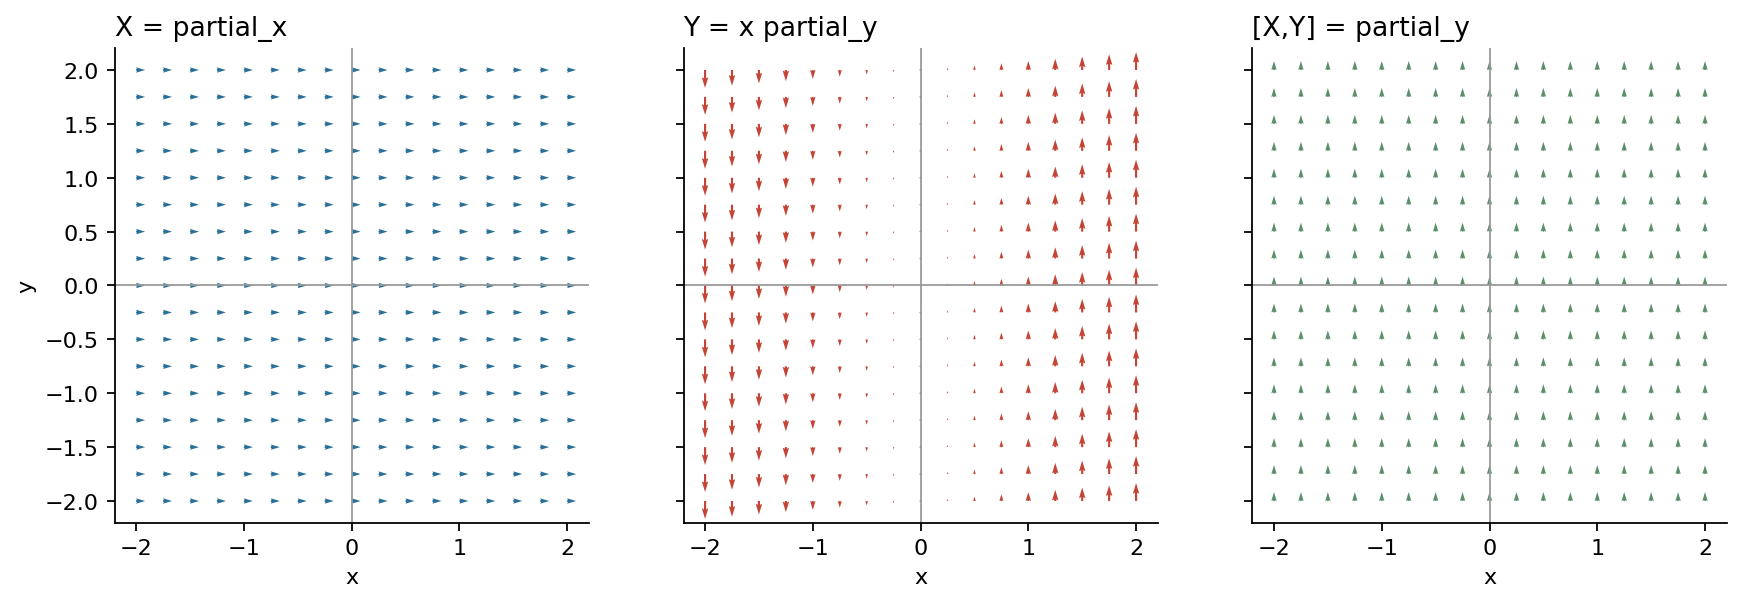

In [7]:
def bracket_components(A, B, variables=(x, y)):
    return sp.Matrix([
        sp.simplify(sum(A[j] * sp.diff(B[i], variables[j]) - B[j] * sp.diff(A[i], variables[j]) for j in range(len(variables))))
        for i in range(len(variables))
    ])

X_simple = sp.Matrix([1, 0])
Y_simple = sp.Matrix([0, x])
bracket_simple = bracket_components(X_simple, Y_simple)
coord_bracket = bracket_components(sp.Matrix([1, 0]), sp.Matrix([0, 1]))

A_field = sp.Matrix([1, y])
B_field = sp.Matrix([x, 0])
C_field = sp.Matrix([0, x * y])
jacobi = sp.simplify(
    bracket_components(A_field, bracket_components(B_field, C_field))
    + bracket_components(B_field, bracket_components(C_field, A_field))
    + bracket_components(C_field, bracket_components(A_field, B_field))
)

f0 = x + 2
g0 = y + 3
lhs = bracket_components(f0 * A_field, g0 * B_field)
rhs = sp.simplify(
    f0 * g0 * bracket_components(A_field, B_field)
    + f0 * (sum(A_field[j] * sp.diff(g0, (x, y)[j]) for j in range(2))) * B_field
    - g0 * (sum(B_field[j] * sp.diff(f0, (x, y)[j]) for j in range(2))) * A_field
)
product_bracket_residual = sp.simplify(lhs - rhs)

q = np.linspace(-2.0, 2.0, 17)
XQ, YQ = np.meshgrid(q, q)
fields = [
    ("X = partial_x", np.ones_like(XQ), np.zeros_like(YQ), "#2a6f97"),
    ("Y = x partial_y", np.zeros_like(XQ), XQ, "#c44536"),
    ("[X,Y] = partial_y", np.zeros_like(XQ), np.ones_like(YQ), "#5b8f6a"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharex=True, sharey=True)
for ax, (title, Uv, Vv, color) in zip(axes, fields):
    ax.quiver(XQ, YQ, Uv, Vv, color=color, angles="xy", scale_units="xy", scale=12, width=0.0045)
    ax.axvline(0, color="#999999", lw=0.8)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
bracket_path = save_matplotlib(fig, FIGURES / "lie-bracket-coordinate-check.png")
plt.close(fig)

bracket_check = {
    "example": {"X": "partial_x", "Y": "x*partial_y", "bracket": [str(v) for v in bracket_simple]},
    "coordinate_bracket_partial_x_partial_y": [str(v) for v in coord_bracket],
    "jacobi_components": [str(v) for v in jacobi],
    "product_bracket_residual": [str(v) for v in product_bracket_residual],
    "checks": {
        "example_bracket_is_partial_y": list(bracket_simple) == [0, 1],
        "coordinate_fields_commute": list(coord_bracket) == [0, 0],
        "jacobi_identity_exact": list(jacobi) == [0, 0],
        "product_rule_exact": list(product_bracket_residual) == [0, 0],
    },
}
bracket_check_path = save_json(bracket_check, CHECKS / "lie-bracket-coordinate-checks.json")
display_artifact(bracket_path, width=900)


## Lie Algebra of a Lie Group: Left-Invariant Fields

The Lie algebra of a Lie group is finite-dimensional because a left-invariant field is determined by its value at the identity. To make the bracket visible without requiring matrix-heavy pictures, use the orientation-preserving affine group of the line:

`(a,b)(c,d) = (ac, ad+b)`, with `a>0`.

The identity is `(1,0)`. A tangent vector at the identity with basis values `e_1=(1,0)` and `e_2=(0,1)` propagates by left translation to

`E_1 = a partial_a`, `E_2 = a partial_b`.

These fields are left-invariant, and their bracket is `[E_1,E_2]=E_2`, matching the matrix commutator in the representation `[[a,b],[0,1]]`.


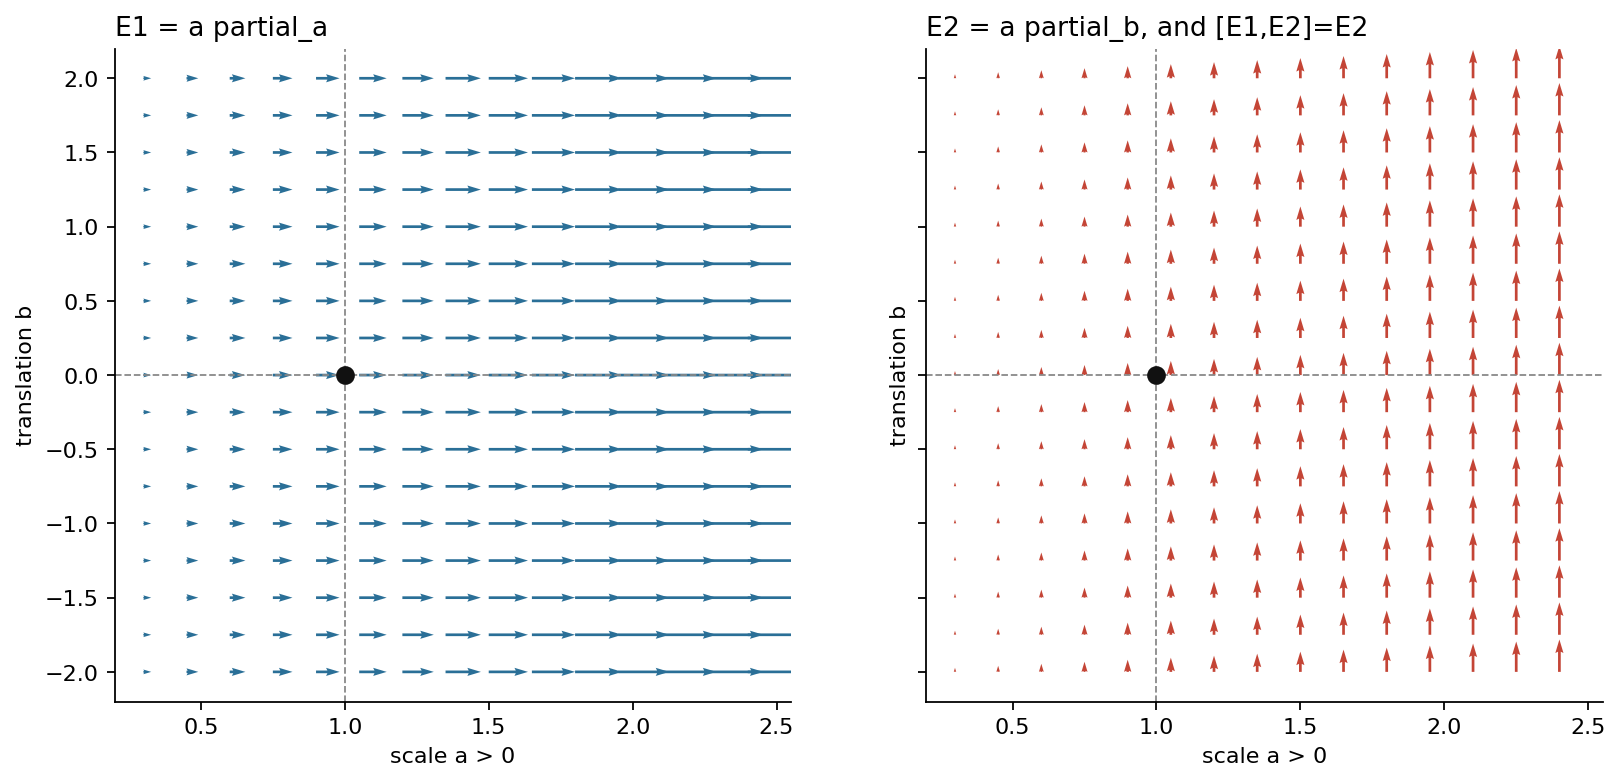

In [8]:
a, b = sp.symbols("a b", positive=True, real=True)
E1 = sp.Matrix([a, 0])
E2 = sp.Matrix([0, a])

def bracket_ab(A, B):
    return sp.Matrix([
        sp.simplify(A[0] * sp.diff(B[i], a) + A[1] * sp.diff(B[i], b) - B[0] * sp.diff(A[i], a) - B[1] * sp.diff(A[i], b))
        for i in range(2)
    ])

affine_bracket = bracket_ab(E1, E2)
A_matrix = sp.Matrix([[1, 0], [0, 0]])
B_matrix = sp.Matrix([[0, 1], [0, 0]])
matrix_commutator = sp.simplify(A_matrix * B_matrix - B_matrix * A_matrix)

aa = np.linspace(0.3, 2.4, 15)
bb = np.linspace(-2.0, 2.0, 17)
AA, BB = np.meshgrid(aa, bb)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True)
axes[0].quiver(AA, BB, AA, np.zeros_like(AA), color="#2a6f97", angles="xy", scale_units="xy", scale=11, width=0.004)
axes[0].scatter([1], [0], s=55, color="#111111", zorder=4)
axes[0].set_title("E1 = a partial_a")
axes[1].quiver(AA, BB, np.zeros_like(AA), AA, color="#c44536", angles="xy", scale_units="xy", scale=11, width=0.004)
axes[1].scatter([1], [0], s=55, color="#111111", zorder=4)
axes[1].set_title("E2 = a partial_b, and [E1,E2]=E2")
for ax in axes:
    ax.set_xlabel("scale a > 0")
    ax.set_ylabel("translation b")
    ax.axvline(1, color="#888888", lw=0.8, ls="--")
    ax.axhline(0, color="#888888", lw=0.8, ls="--")
    ax.set_xlim(0.2, 2.55)
    ax.set_ylim(-2.2, 2.2)
affine_path = save_matplotlib(fig, FIGURES / "affine-group-left-invariant-fields.png")
plt.close(fig)

trace_A = sp.symbols("eps")
M = sp.Matrix([[1, 0], [0, 1]]) + trace_A * sp.Matrix([[2, -1], [3, 4]])
determinant_derivative = sp.diff(sp.det(M), trace_A).subs(trace_A, 0)
trace_derivative = sp.trace(sp.Matrix([[2, -1], [3, 4]]))
commutator_trace = sp.trace(matrix_commutator)

affine_check = {
    "group_law": "(a,b)(c,d)=(ac,ad+b)",
    "left_invariant_basis": {"E1": ["a", "0"], "E2": ["0", "a"]},
    "bracket_E1_E2": [str(v) for v in affine_bracket],
    "matrix_commutator_basis": [[str(item) for item in row] for row in matrix_commutator.tolist()],
    "determinant_derivative_at_identity": str(determinant_derivative),
    "trace_of_test_matrix": str(trace_derivative),
    "trace_of_commutator": str(commutator_trace),
    "checks": {
        "affine_bracket_equals_E2": list(affine_bracket) == [0, a],
        "matrix_commutator_equals_B": matrix_commutator == B_matrix,
        "det_derivative_equals_trace": sp.simplify(determinant_derivative - trace_derivative) == 0,
        "trace_kills_commutators": commutator_trace == 0,
    },
}
affine_check_path = save_json(affine_check, CHECKS / "affine-group-left-invariant-fields.json")
display_artifact(affine_path, width=840)


## Examples and Failure Modes

Keep these examples separate in your head:

- `R^n`, `S^1`, and tori have abelian Lie algebras in their standard translation/angle coordinates because the relevant coordinate fields commute.
- `GL(n)` has the matrix commutator as its bracket after identifying the tangent space at the identity with matrices.
- The affine group above is the smallest visible nonabelian model in this notebook: two dimensions, one nonzero bracket.
- A smooth map that is not a diffeomorphism can fail to push a vector field to the target because different points in the same fiber may demand different target vectors.
- A field on a manifold need not restrict to a submanifold unless it is tangent along that submanifold.


## Applied Lab: When Does the Bracket Vanish?

Consider the family `X=partial_x`, `Y_k=x^k partial_y`. The bracket is `k x^(k-1) partial_y`. This small family is a diagnostic lab for the whole chapter: coordinate expressions are easy, the derivation rule computes the bracket exactly, and the failure of commuting is visible as soon as `k>0`.


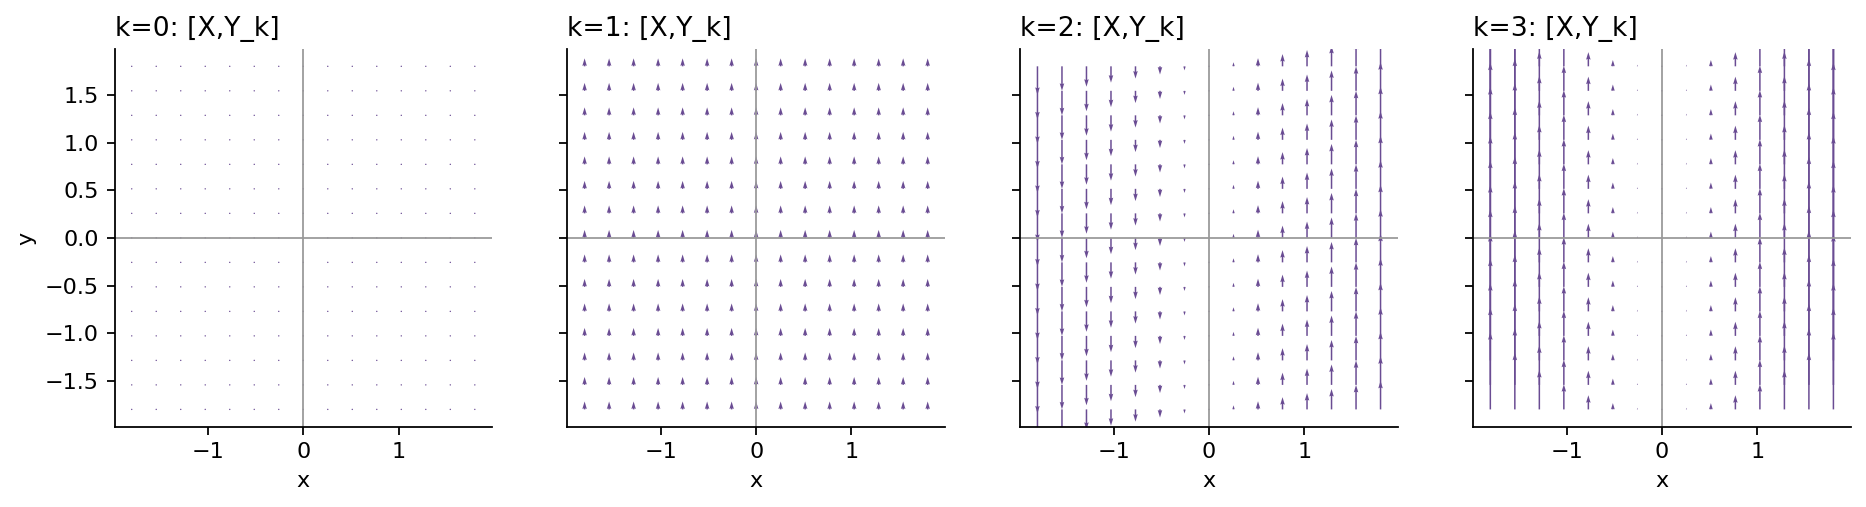

[applied-lab-bracket-parameter.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/chapter-08-vector-fields/tables/applied-lab-bracket-parameter.csv)

In [9]:
k_values = [0, 1, 2, 3]
lab_rows = []
fig, axes = plt.subplots(1, len(k_values), figsize=(14, 3.8), sharex=True, sharey=True)
q = np.linspace(-1.8, 1.8, 15)
LX, LY = np.meshgrid(q, q)
for ax, kval in zip(axes, k_values):
    Yk = sp.Matrix([0, x**kval])
    bracket_k = bracket_components(sp.Matrix([1, 0]), Yk)
    lab_rows.append({"k": kval, "bracket": [str(v) for v in bracket_k], "commutes": list(bracket_k) == [0, 0]})
    BV = np.zeros_like(LX) if kval == 0 else kval * (LX ** (kval - 1))
    ax.quiver(LX, LY, np.zeros_like(LX), BV, color="#6a4c93", angles="xy", scale_units="xy", scale=12, width=0.004)
    ax.axvline(0, color="#999999", lw=0.8)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.set_title(f"k={kval}: [X,Y_k]")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
lab_path = save_matplotlib(fig, FIGURES / "applied-lab-bracket-parameter.png")
plt.close(fig)
lab_table_path = save_csv(lab_rows, TABLES / "applied-lab-bracket-parameter.csv")
lab_check_path = save_json(
    {
        "family": "X=partial_x, Y_k=x^k partial_y",
        "rows": lab_rows,
        "checks": {
            "k0_commutes": lab_rows[0]["commutes"],
            "positive_k_nonzero_somewhere": all(not row["commutes"] for row in lab_rows[1:]),
        },
    },
    CHECKS / "applied-lab-bracket-parameter.json",
)
display_artifact(lab_path, width=900)
display_artifact(lab_table_path, width=760)


## Takeaways

- A vector field is a smooth section of `TM`; in coordinates this becomes smooth component functions.
- Acting on functions turns a field into a derivation, and derivations are the safest way to understand why the Lie bracket is coordinate-free.
- Related fields are controlled by `dF_p(X_p)=Y_{F(p)}`. Pushforwards are automatic for diffeomorphisms and fragile for maps with nontrivial fibers.
- The Lie bracket is natural under related fields, so it survives pushforwards, restrictions to tangent submanifolds, and Lie group homomorphisms in exactly the cases where the hypotheses say it should.
- A Lie group's Lie algebra can be read from left-invariant fields; evaluation at the identity turns an infinite-looking space of fields into a finite-dimensional algebra.


In [10]:
final_checks = {
    "concept_graph_paths": {
        "section_to_lie_algebra": nx.has_path(G, "smooth section of TM", "Lie algebra of a Lie group"),
        "related_to_induced": nx.has_path(G, "related fields", "induced Lie algebra homomorphism"),
    },
    "section": {
        "tangent_to_circle": section_check["max_abs_radial_dot"] < 1e-12,
        "unit_norm": section_check["max_abs_norm_error"] < 1e-12,
    },
    "coordinate_expression": coordinate_check["checks"],
    "acts_on_functions": acts_check["checks"],
    "pushforward_related_fields": pushforward_check["checks"],
    "lie_bracket": bracket_check["checks"],
    "affine_lie_group": affine_check["checks"],
    "applied_lab": {
        "k0_commutes": lab_rows[0]["commutes"],
        "k1_bracket_is_partial_y": lab_rows[1]["bracket"] == ["0", "1"],
    },
}
expected_paths = [
    source_span_path,
    routing_path,
    storyboard_path,
    concept_graph_path,
    concept_graph_check_path,
    section_path,
    section_check_path,
    coordinate_path,
    coordinate_check_path,
    acts_path,
    acts_check_path,
    pushforward_path,
    fold_html_path,
    pushforward_check_path,
    bracket_path,
    bracket_check_path,
    affine_path,
    affine_check_path,
    lab_path,
    lab_table_path,
    lab_check_path,
]
flattened = []
for group in final_checks.values():
    if isinstance(group, dict):
        flattened.extend(bool(value) for value in group.values())
    else:
        flattened.append(bool(group))
if not all(flattened):
    raise AssertionError(json.dumps(final_checks, indent=2))

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 174-204",
    "artifact_count_before_final_json": len(expected_paths),
    "artifacts": [str(Path(path).relative_to(BOOK_ROOT)) for path in expected_paths],
    "checks": final_checks,
    "status": "passed",
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
expected_paths.append(final_sanity_path)
assert_artifacts(expected_paths, min_bytes=80)
print(json.dumps(final_sanity, indent=2))


{
  "unit": "Vector Fields",
  "source_span": "printed pages 174-204",
  "artifact_count_before_final_json": 21,
  "artifacts": [
    "artifacts\\chapter-08-vector-fields\\checks\\source-span-vector-fields.json",
    "artifacts\\chapter-08-vector-fields\\tables\\vector-fields-library-routing.csv",
    "artifacts\\chapter-08-vector-fields\\tables\\vector-fields-visual-storyboard.csv",
    "artifacts\\chapter-08-vector-fields\\figures\\vector-fields-concept-dependency.png",
    "artifacts\\chapter-08-vector-fields\\checks\\vector-fields-concept-dependency.json",
    "artifacts\\chapter-08-vector-fields\\figures\\vector-fields-section-as-graph.png",
    "artifacts\\chapter-08-vector-fields\\checks\\vector-fields-section-as-graph.json",
    "artifacts\\chapter-08-vector-fields\\figures\\coordinate-expression-rotation-field.png",
    "artifacts\\chapter-08-vector-fields\\checks\\coordinate-expression-rotation-field.json",
    "artifacts\\chapter-08-vector-fields\\figures\\vector-field-acts-